# Pollen Grain Image Classification

Pipeline:
1. Download the Kaggle dataset.
2. Validate & organize images into class folders.
3. **Augment data on disk** to grow the training set (small dataset → needs more samples).
4. Build a CNN with transfer learning (MobileNetV2) + in-model augmentation.
5. Train with callbacks (EarlyStopping + ReduceLROnPlateau).
6. Evaluate and visualize predictions.
7. **Export the trained model as `model.zip`** for download from Lightning AI.

### Install dependencies (Lightning AI environment)

In [1]:
!pip install -q kagglehub tensorflow pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 897.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 102.3 MB/s eta 0:00:00


### Downloading Data & visualizing it

In [2]:
import kagglehub

path = kagglehub.dataset_download('andrewmvd/pollen-grain-image-classification')
print("Path to dataset files:", path)

100%|██████████| 24.1M/24.1M [00:00<00:00, 51.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/pollen-grain-image-classification/versions/1


Found 790 images.


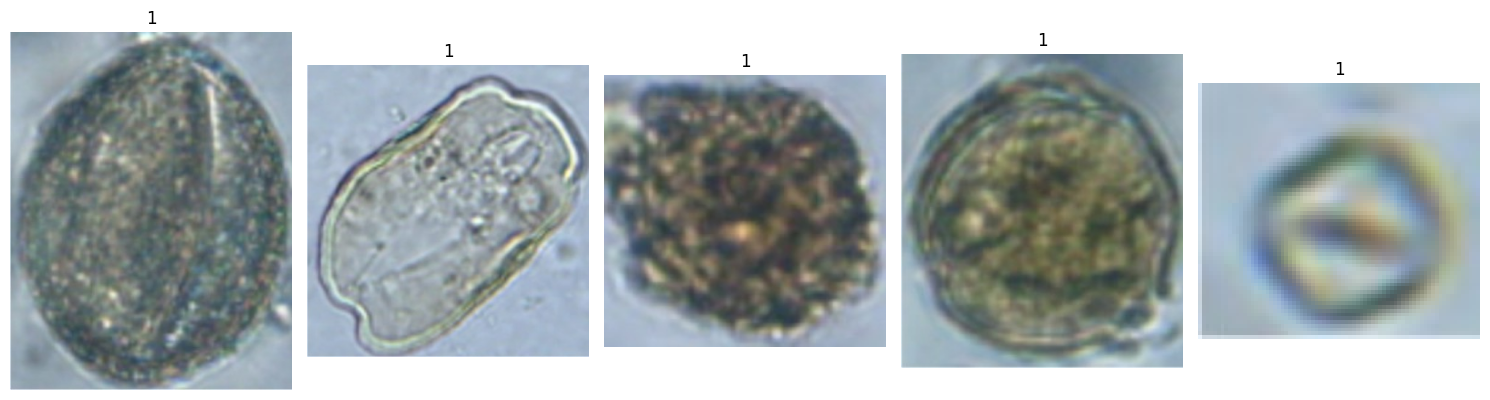

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

print(f"Found {len(image_files)} images.")

num_images_to_show = 5
if num_images_to_show > 0 and len(image_files) >= num_images_to_show:
    plt.figure(figsize=(15, 5))
    for i in range(num_images_to_show):
        img_path = image_files[i]
        img = Image.open(img_path)
        plt.subplot(1, num_images_to_show, i + 1)
        plt.imshow(img)
        label = os.path.basename(img_path.split(os.sep)[-2])
        plt.title(label)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### Organizing data inside workdir

In [4]:
import os
import shutil
from PIL import Image as PILImage

organized_path = "./data/organized_pollen_data"

if os.path.exists(organized_path):
    shutil.rmtree(organized_path)
os.makedirs(organized_path, exist_ok=True)

print("Starting to organize files...")

skipped = 0
copied = 0

for img_path in image_files:
    try:
        with PILImage.open(img_path) as img:
            img.verify()
        if PILImage.open(img_path).format not in ('JPEG', 'PNG', 'GIF', 'BMP', 'WEBP'):
            skipped += 1
            continue
    except Exception:
        skipped += 1
        continue

    filename = os.path.basename(img_path)
    parts = filename.split('_')
    class_name = "_".join(parts[:-1])

    class_folder = os.path.join(organized_path, class_name)
    os.makedirs(class_folder, exist_ok=True)

    dest_path = os.path.join(class_folder, filename)
    shutil.copy(img_path, dest_path)
    copied += 1

print(f"\nDone! Copied {copied} valid images, skipped {skipped} invalid files.")
print(f"Data organized into: {organized_path}")

Starting to organize files...

Done! Copied 699 valid images, skipped 91 invalid files.
Data organized into: ./data/organized_pollen_data


### Growing the dataset — offline augmentation on disk

We physically generate augmented copies of every image so the training set grows from a few hundred to several thousand samples. This is on top of the in-model augmentation layers we'll add later.

In [5]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image as PILImage

AUG_COPIES_PER_IMAGE = 7
IMAGE_SIZE = (224, 224)

augment_pipeline = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.25),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
])

total_generated = 0
for class_name in os.listdir(organized_path):
    class_dir = os.path.join(organized_path, class_name)
    if not os.path.isdir(class_dir):
        continue

    originals = [f for f in os.listdir(class_dir)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for fname in originals:
        src = os.path.join(class_dir, fname)
        try:
            img = PILImage.open(src).convert('RGB').resize(IMAGE_SIZE)
        except Exception:
            continue
        arr = tf.keras.utils.img_to_array(img)
        arr = tf.expand_dims(arr, 0)

        base, _ = os.path.splitext(fname)
        for i in range(AUG_COPIES_PER_IMAGE):
            aug = augment_pipeline(arr, training=True)
            aug = tf.clip_by_value(aug, 0.0, 255.0)
            aug_img = PILImage.fromarray(np.array(aug[0]).astype('uint8'))
            out_name = f"{base}_aug{i}.jpg"
            aug_img.save(os.path.join(class_dir, out_name), 'JPEG', quality=92)
            total_generated += 1

print(f"Generated {total_generated} augmented images on disk.")

total_after = 0
for class_name in os.listdir(organized_path):
    class_dir = os.path.join(organized_path, class_name)
    if not os.path.isdir(class_dir):
        continue
    n = len([f for f in os.listdir(class_dir)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    total_after += n
    print(f"  {class_name}: {n} images")
print(f"\nTotal images after augmentation: {total_after}")

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Generated 4585 augmented images on disk.
  serjania: 272 images
  qualea: 280 images
  matayba: 280 images
  hyptis: 280 images
  mimosa: 280 images
  arrabidaea: 280 images
  mabea: 280 images
  anadenanthera: 160 images
  dipteryx: 280 images
  faramea: 280 images
  protium: 280 images
  schinus: 280 images
  eucalipto: 280 images
  croton: 280 images
  tridax: 280 images
  combretum: 280 images
  myrcia: 32 images
  arecaceae: 280 images
  chromolaena: 280 images
  syagrus: 248 images
  cecropia: 48 images

Total images after augmentation: 5240


### Build train / validation datasets

In [6]:
import tensorflow as tf

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

print("Loading data...")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    organized_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    organized_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Found {num_classes} different types of pollen:")
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Loading data...
Found 5240 files belonging to 21 classes.
Using 4192 files for training.
Found 5240 files belonging to 21 classes.
Using 1048 files for validation.
Found 21 different types of pollen:
['anadenanthera', 'arecaceae', 'arrabidaea', 'cecropia', 'chromolaena', 'combretum', 'croton', 'dipteryx', 'eucalipto', 'faramea', 'hyptis', 'mabea', 'matayba', 'mimosa', 'myrcia', 'protium', 'qualea', 'schinus', 'serjania', 'syagrus', 'tridax']


### Building the model — MobileNetV2 transfer learning + in-model augmentation

On small datasets, transfer learning beats a from-scratch CNN by a wide margin. We freeze the backbone, train a classification head, then optionally fine-tune.

In [7]:
print("Building the model...")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
], name='data_augmentation')

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Building the model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424,661 (9.25 MB)

 Trainable params: 166,677 (651.08 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Stage 1 — train the classification head

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
    ),
]

EPOCHS_HEAD = 11
history_head = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
)
print("Stage 1 complete.")

Epoch 1/11
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 811ms/step - accuracy: 0.7304 - loss: 0.8350 - val_accuracy: 0.8426 - val_loss: 0.5024 - learning_rate: 0.0010
Epoch 2/11
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 801ms/step - accuracy: 0.8125 - loss: 0.5818 - val_accuracy: 0.8607 - val_loss: 0.4194 - learning_rate: 0.0010
Epoch 3/11
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 803ms/step - accuracy: 0.8333 - loss: 0.5049 - val_accuracy: 0.8845 - val_loss: 0.3349 - learning_rate: 0.0010
Epoch 4/11
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 801ms/step - accuracy: 0.8442 - loss: 0.4510 - val_accuracy: 0.8960 - val_loss: 0.2937 - learning_rate: 0.0010
Epoch 5/11
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 803ms/step - accuracy: 0.8585 - loss: 0.4037 - val_accuracy: 0.9027 - val_loss: 0.2899 - learning_rate: 0.0010
Epoch 6/11
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 802ms/step - accuracy: 0.8612 - loss: 0.3978 - val_accuracy: 0.9198 - val_loss: 0.2375 - learning_rate: 0.0010
Epoch 7/11
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 805ms/step - accura

### Stage 2 — fine-tune the top of the backbone

In [11]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

EPOCHS_FT = 9
history_ft = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_HEAD + EPOCHS_FT,
    initial_epoch=len(history_head.history['accuracy']),
    callbacks=callbacks,
)
print("Stage 2 (fine-tuning) complete.")

Epoch 12/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7860 - loss: 0.6644 - val_accuracy: 0.9141 - val_loss: 0.2418 - learning_rate: 1.0000e-05
Epoch 13/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 997ms/step - accuracy: 0.8333 - loss: 0.5071 - val_accuracy: 0.9198 - val_loss: 0.2375 - learning_rate: 1.0000e-05
Epoch 14/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 995ms/step - accuracy: 0.8511 - loss: 0.4520 - val_accuracy: 0.9170 - val_loss: 0.2336 - learning_rate: 5.0000e-06
Epoch 15/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 996ms/step - accuracy: 0.8612 - loss: 0.4221 - val_accuracy: 0.9151 - val_loss: 0.2315 - learning_rate: 5.0000e-06
Epoch 16/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 996ms/step - accuracy: 0.8671 - loss: 0.4012 - val_accuracy: 0.9179 - val_loss: 0.2267 - learning_rate: 2.5000e-06
Stage 2 (fine-tuning) complete.


### Training curves

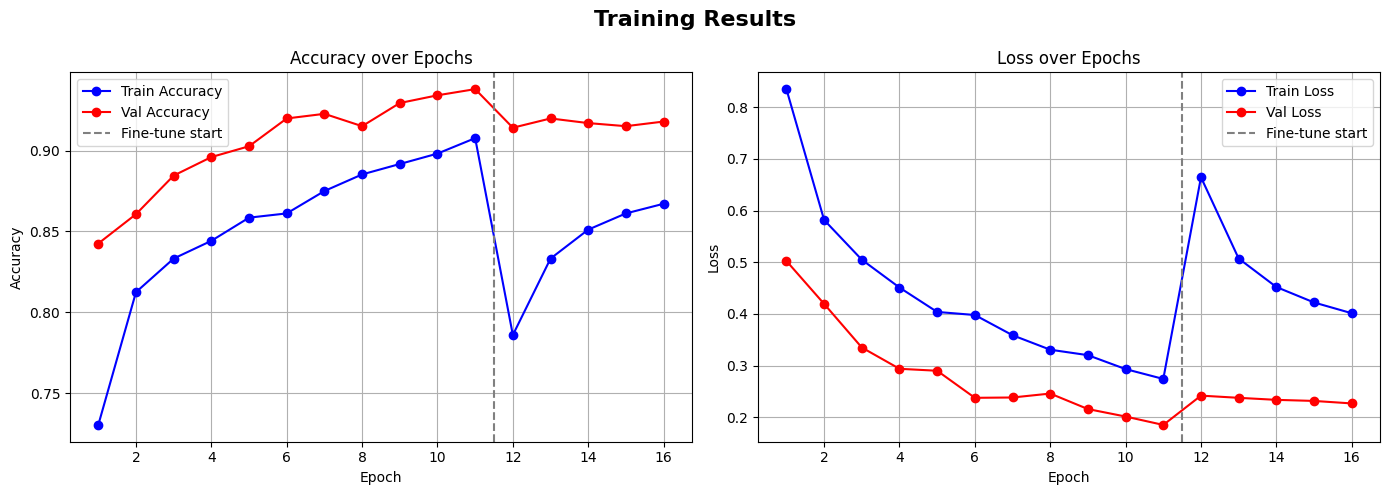

In [12]:
import matplotlib.pyplot as plt

acc      = history_head.history['accuracy']     + history_ft.history['accuracy']
val_acc  = history_head.history['val_accuracy'] + history_ft.history['val_accuracy']
loss     = history_head.history['loss']         + history_ft.history['loss']
val_loss = history_head.history['val_loss']     + history_ft.history['val_loss']
epochs_x = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Results', fontsize=16, fontweight='bold')

axes[0].plot(epochs_x, acc,     'b-o', label='Train Accuracy')
axes[0].plot(epochs_x, val_acc, 'r-o', label='Val Accuracy')
axes[0].axvline(x=len(history_head.history['accuracy']) + 0.5,
                color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_x, loss,     'b-o', label='Train Loss')
axes[1].plot(epochs_x, val_loss, 'r-o', label='Val Loss')
axes[1].axvline(x=len(history_head.history['loss']) + 0.5,
                color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Predict on 5 Sample Images

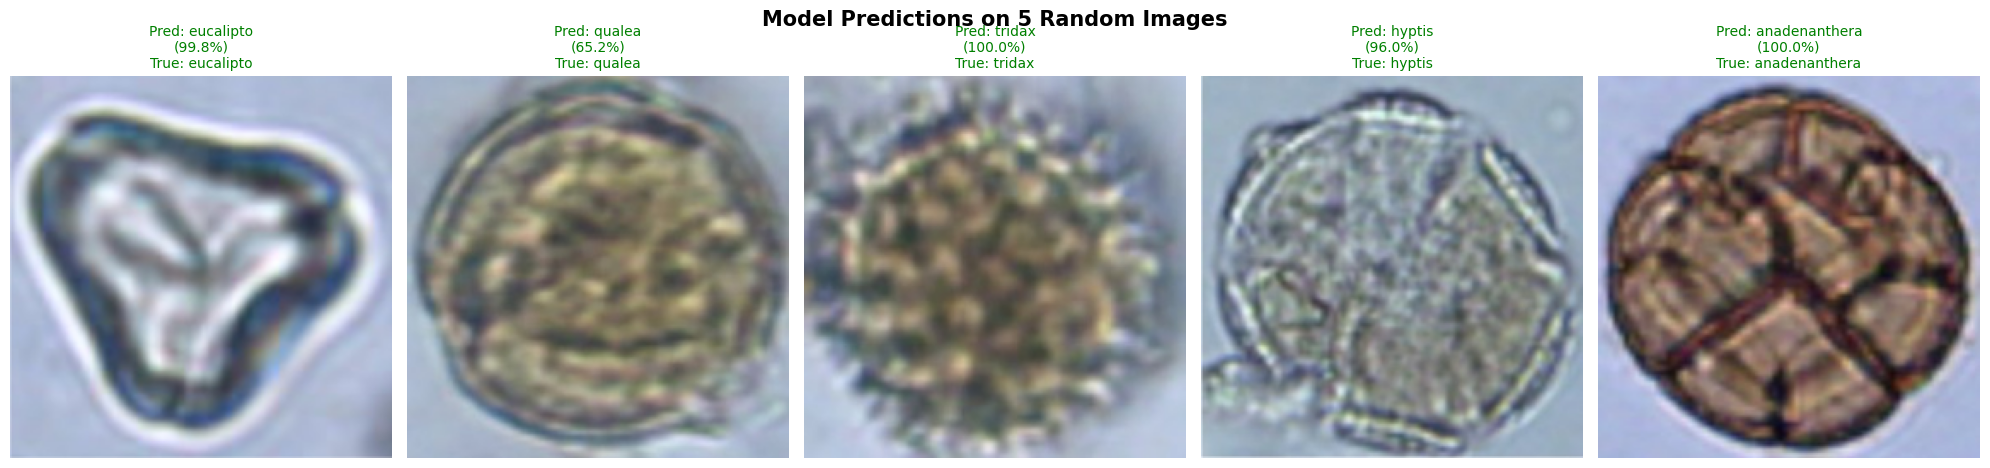

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image as PILImage
import random, os

all_image_paths = []
all_image_labels = []
for class_name in os.listdir(organized_path):
    class_dir = os.path.join(organized_path, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if '_aug' in fname:
            continue
        all_image_paths.append(os.path.join(class_dir, fname))
        all_image_labels.append(class_name)

sample_indices = random.sample(range(len(all_image_paths)), 5)
sample_paths   = [all_image_paths[i] for i in sample_indices]
sample_labels  = [all_image_labels[i] for i in sample_indices]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Model Predictions on 5 Random Images', fontsize=15, fontweight='bold')

for ax, img_path, true_label in zip(axes, sample_paths, sample_labels):
    img = PILImage.open(img_path).convert('RGB').resize(IMAGE_SIZE)
    img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)

    predictions  = model.predict(img_array, verbose=0)[0]
    predicted_idx   = np.argmax(predictions)
    predicted_class = class_names[predicted_idx]
    confidence      = predictions[predicted_idx] * 100

    color = 'green' if predicted_class == true_label else 'red'
    ax.imshow(img)
    ax.set_title(
        f"Pred: {predicted_class}\n({confidence:.1f}%)\nTrue: {true_label}",
        color=color, fontsize=10,
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

### Export the trained model as `model.zip`

Saves the Keras model + the class names, then zips everything into `model.zip` ready to be downloaded from Lightning AI.

In [14]:
import os
import json
import shutil

export_dir = "./model_export"
if os.path.exists(export_dir):
    shutil.rmtree(export_dir)
os.makedirs(export_dir, exist_ok=True)

model.save(os.path.join(export_dir, "model.keras"))

with open(os.path.join(export_dir, "class_names.json"), "w") as f:
    json.dump(class_names, f, indent=2)

with open(os.path.join(export_dir, "metadata.json"), "w") as f:
    json.dump({
        "image_size": list(IMAGE_SIZE),
        "num_classes": num_classes,
        "preprocessing": "mobilenet_v2.preprocess_input (applied inside the model)",
        "framework": f"tensorflow {tf.__version__}",
    }, f, indent=2)

zip_base = "./model"
if os.path.exists(zip_base + ".zip"):
    os.remove(zip_base + ".zip")
shutil.make_archive(zip_base, 'zip', export_dir)

zip_path = os.path.abspath(zip_base + ".zip")
print(f"\n model exported → {zip_path}")
print(f" size: {os.path.getsize(zip_path) / (1024*1024):.2f} MB")
print("\nDownload `model.zip` from the Lightning AI file browser.")


 model exported → /content/model.zip
 size: 20.31 MB

Download `model.zip` from the Lightning AI file browser.


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
